In [1]:
print("Radiotherapy Image Quality Toolkit")

Radiotherapy Image Quality Toolkit


In [2]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

print("Current folder:", Path.cwd())
print("Using src folder:", src_path)

Current folder: c:\Users\Yifen\OneDrive\Documents\GitHub\radiotherapy-image-quality-toolkit\notebook
Using src folder: c:\Users\Yifen\OneDrive\Documents\GitHub\radiotherapy-image-quality-toolkit\src


In [3]:
import pydicom
import pandas as pd

from pydicom.data import get_testdata_file

from dicom_reader import load_dicom
from batch_analysis import analyze_dicom_folder

from roi_analysis import (
    calculate_roi_statistics,
    calculate_snr,
    calculate_cnr,
    summarize_analysis,
    calculate_circular_roi_statistics
)

from visualization import (
    show_dicom_image,
    show_roi,
    show_two_rois
)

from roi_selector import (
    select_rectangular_roi,
    select_circular_roi
)

print("pydicom version:", pydicom.__version__)

pydicom version: 3.0.2


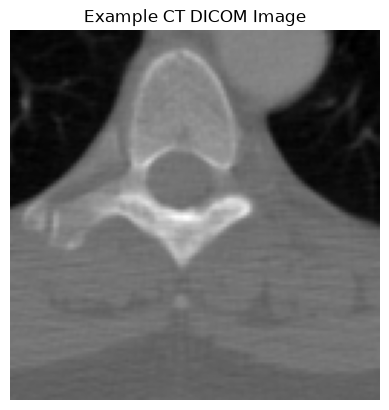

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 192
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: CT Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.3.6.1.4.1.5962.1.1.1.1.1.20040119072730.12322
(0002,0010) Transfer Syntax UID                 UI: Explicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.3.6.1.4.1.5962.2
(0002,0013) Implementation Version Name         SH: 'DCTOOL100'
(0002,0016) Source Application Entity Title     AE: 'CLUNIE1'
-------------------------------------------------
(0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'AXIAL']
(0008,0012) Instance Creation Date              DA: '20040119'
(0008,0013) Instance Creation Time              TM: '072731'
(0008,0014) Instance Creator UID                UI: 1.3.6.1.4.

In [4]:

dicom_path = get_testdata_file("CT_small.dcm")

ds, image = load_dicom(dicom_path)

show_dicom_image(
    image,
    title="Example CT DICOM Image"
)

print(ds)

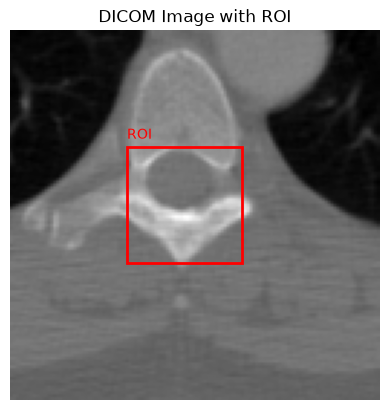

In [5]:
# Define a simple rectangular ROI
x1, x2 = 40, 80
y1, y2 = 40, 80

show_roi(
    image,
    x1, x2,
    y1, y2,
    label="ROI"
)


In [6]:
# Target ROI
roi_mean, roi_std = calculate_roi_statistics(
    image,
    x1, x2,
    y1, y2
)

snr = calculate_snr(
    image,
    x1, x2,
    y1, y2
)

print("ROI Mean:", roi_mean)
print("ROI SD:", roi_std)
print("SNR:", snr)

ROI Mean: 1307.86375
ROI SD: 272.6073071946853
SNR: 4.797610759076153


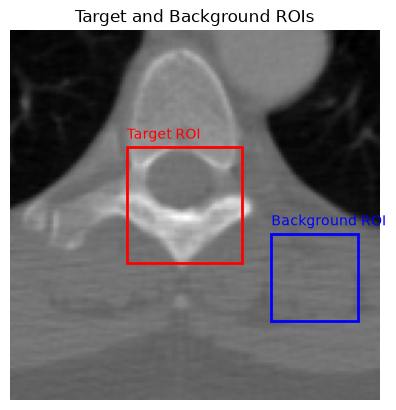

In [7]:
# Define dual simple rectangular ROI
target_coords = (40, 80, 40, 80)
background_coords = (90, 120, 70, 100)

show_two_rois(
    image,
    target_coords,
    background_coords
)

In [8]:
results = summarize_analysis(
    image,
    target_coords,
    background_coords
)

results_df = pd.DataFrame(
    list(results.items()),
    columns=["Metric", "Value"]
)

results_df

,Metric,Value
0,Target Mean,1307.863750
1,Target SD,272.607307
2,Background Mean,1039.221111
3,Background SD,37.655588
4,SNR,4.797611
5,CNR,7.134204


Number of DICOM files: 11
Loaded file: 10FFF_0_RI.1.2.246.352.62.1.5256797380986147081.7509215527051679670.dcm
Image type: <class 'numpy.ndarray'>
Image shape: (768, 1024)


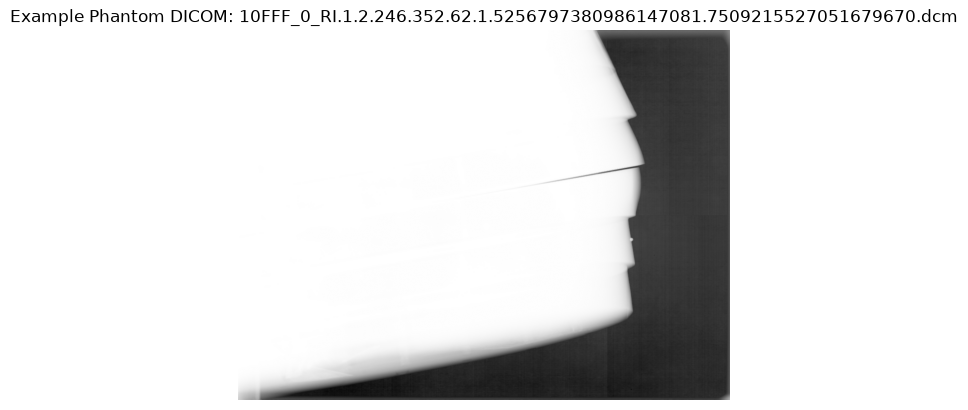

In [ ]:
# Phantom DICOM Test Data
test_data_folder = project_root / "test_data"

dicom_files = list(test_data_folder.glob("*.dcm"))

print("Number of DICOM files:", len(dicom_files))

example_file = dicom_files[0]

ds, example_image = load_dicom(example_file)

print("Loaded file:", example_file.name)
print("Image type:", type(example_image))
print("Image shape:", example_image.shape)

show_dicom_image(
    example_image,
    title=f"Example Phantom DICOM: {example_file.name}"
)

In [10]:
%matplotlib inline